## 1. Setup do ambiente

In [1]:
# Monta o Google Drive (necessário no Colab)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q albumentations==1.4.15 opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 18.5 MB/s eta 0:00:00


In [3]:
import os
import glob
import random
import time
import copy
import json

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
# Caminhos base no Drive
BASE_DIR = "/content/drive/MyDrive/LIPAI/S19"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")           # dataset/healthy, dataset/severe
MASKS_DIR = os.path.join(BASE_DIR, "reference_masks")     # reference_masks/healthy, reference_masks/severe
OUTPUT_MASKS_DIR = os.path.join(BASE_DIR, "unet_masks")   # onde as máscaras preditas serão salvas

os.makedirs(OUTPUT_MASKS_DIR, exist_ok=True)

GROUPS = ["healthy", "severe"]
IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

for g in GROUPS:
    print(g, "->", os.path.join(DATASET_DIR, g))


healthy -> /content/drive/MyDrive/LIPAI/S19/dataset/healthy
severe -> /content/drive/MyDrive/LIPAI/S19/dataset/severe


## 2. Arquitetura U-Net

Abaixo está o código de referência (`ConvBlock`, `Encoder`) já fornecido, e as
implementações de `Bottleneck`, `UpConvBlock`, `FinalConv`, `Decoder` e da
classe completa `UNet`.


In [5]:
class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        batchnorm=True,
        dropout_rate=0.0,
    ):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(num_features=out_channels) if batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(num_features=out_channels) if batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
        )

    def forward(self, x):
        return self.conv(x)


class Encoder(nn.Module):
    def __init__(self, in_channels, batchnorm, dropout_rate=0.0):
        super(Encoder, self).__init__()
        self.conv_blocks = nn.ModuleList(
            [
                ConvBlock(
                    in_channels=in_channels,
                    out_channels=64,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=64,
                    out_channels=128,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=128,
                    out_channels=256,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=256,
                    out_channels=512,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
            ]
        )
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip_connections = []
        for conv_block in self.conv_blocks:
            x = conv_block(x)
            skip_connections.append(x)
            x = self.max_pool(x)
        return x, skip_connections


In [6]:
class Bottleneck(nn.Module):
    """Bloco central da U-Net: 512 -> 1024 canais, duas convoluções 3x3."""

    def __init__(self, batchnorm, dropout_rate=0.0, in_channels=512, out_channels=1024):
        super(Bottleneck, self).__init__()
        self.conv_block = ConvBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            batchnorm=batchnorm,
            dropout_rate=dropout_rate,
        )

    def forward(self, x):
        return self.conv_block(x)


In [7]:
class UpConvBlock(nn.Module):
    """Bloco de upsampling do decoder:
    ConvTranspose2d -> concatenação com a skip connection -> ConvBlock.
    """

    def __init__(self, in_channels, out_channels, batchnorm, dropout_rate=0.0):
        super(UpConvBlock, self).__init__()
        # Upsampling: reduz o número de canais pela metade e dobra a resolução espacial.
        self.up = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size=2, stride=2
        )
        # Após concatenar com a skip connection (mesmo número de canais: out_channels),
        # o número de canais de entrada do ConvBlock é 2 * out_channels.
        self.conv_block = ConvBlock(
            in_channels=out_channels * 2,
            out_channels=out_channels,
            batchnorm=batchnorm,
            dropout_rate=dropout_rate,
        )

    def forward(self, x, skip_connection):
        x = self.up(x)

        # Caso a resolução espacial de x e da skip connection não coincida
        # (por exemplo, entradas com dimensões não potência de 2), aplica-se
        # um center-crop/pad para garantir a concatenação.
        if x.shape[-2:] != skip_connection.shape[-2:]:
            diff_h = skip_connection.shape[-2] - x.shape[-2]
            diff_w = skip_connection.shape[-1] - x.shape[-1]
            x = F.pad(
                x,
                [
                    diff_w // 2, diff_w - diff_w // 2,
                    diff_h // 2, diff_h - diff_h // 2,
                ],
            )

        x = torch.cat([skip_connection, x], dim=1)  # concatenação na dimensão dos canais
        x = self.conv_block(x)
        return x


In [8]:
class FinalConv(nn.Module):
    """Camada final: convolução 1x1 mapeando para o número de classes."""

    def __init__(self, in_channels, num_classes):
        super(FinalConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


In [9]:
class Decoder(nn.Module):
    """Caminho de expansão da U-Net.

    Recebe a saída do bottleneck e as skip connections do encoder (na ordem
    em que foram armazenadas), aplica upsampling + concatenação + convoluções
    repetidamente, usando as skip connections em ordem inversa, e finaliza
    com uma convolução 1x1 para gerar o mapa de segmentação.
    """

    def __init__(self, batchnorm, dropout_rate=0.0, num_classes=2):
        super(Decoder, self).__init__()
        # Canais simétricos ao encoder: 1024 -> 512 -> 256 -> 128 -> 64
        self.up_blocks = nn.ModuleList(
            [
                UpConvBlock(1024, 512, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(512, 256, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(256, 128, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(128, 64, batchnorm=batchnorm, dropout_rate=dropout_rate),
            ]
        )
        self.final_conv = FinalConv(in_channels=64, num_classes=num_classes)

    def forward(self, x, skip_connections):
        # As skip connections foram guardadas em ordem crescente de profundidade
        # (rasa -> profunda); no decoder devem ser usadas em ordem inversa
        # (profunda -> rasa).
        skip_connections = skip_connections[::-1]

        for up_block, skip in zip(self.up_blocks, skip_connections):
            x = up_block(x, skip)

        x = self.final_conv(x)
        return x


In [10]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes=2, dropout_rate=0.0, batchnorm=True):
        super(UNet, self).__init__()
        self.encoder = Encoder(in_channels, batchnorm, dropout_rate=dropout_rate)
        self.bottleneck = Bottleneck(batchnorm, dropout_rate=dropout_rate)
        self.decoder = Decoder(batchnorm, dropout_rate=dropout_rate, num_classes=num_classes)

    def forward(self, x):
        output, skip_connections = self.encoder(x)
        output = self.bottleneck(output)
        output = self.decoder(output, skip_connections)
        return output


if __name__ == "__main__":
    model = UNet(in_channels=3, num_classes=2, batchnorm=False)
    dummy_input = torch.randn(1, 3, 224, 224)
    dummy_output = model(dummy_input)
    print("input shape", dummy_input.shape)
    print("output shape", dummy_output.shape)


input shape torch.Size([1, 3, 224, 224])
output shape torch.Size([1, 2, 224, 224])


## 3. Dataset

A classe `NucleiSegmentationDataset` lê as imagens em
`dataset/{healthy,severe}` e as máscaras correspondentes em
`reference_masks/{healthy,severe}` (mesmo nome de arquivo). As máscaras são
binarizadas (0 = fundo, 1 = núcleo).

Ajuste `build_file_list()` se a organização real dos seus arquivos for
diferente.


In [11]:
def build_file_list(dataset_dir, masks_dir, groups=GROUPS, img_exts=IMG_EXTENSIONS):
    """Retorna uma lista de tuplas (caminho_imagem, caminho_mascara, grupo)
    pareando cada imagem com sua máscara de referência pelo nome do arquivo
    (ignorando a extensão)."""
    pairs = []
    for group in groups:
        img_dir = os.path.join(dataset_dir, group)
        mask_dir = os.path.join(masks_dir, group)

        if not os.path.isdir(img_dir):
            print(f"[aviso] diretório de imagens não encontrado: {img_dir}")
            continue

        # Índice de máscaras disponíveis (nome sem extensão -> caminho completo)
        mask_index = {}
        search_mask_dir = mask_dir if os.path.isdir(mask_dir) else masks_dir
        for mpath in glob.glob(os.path.join(search_mask_dir, "**", "*"), recursive=True):
            if mpath.lower().endswith(img_exts):
                mask_index[os.path.splitext(os.path.basename(mpath))[0]] = mpath

        for ipath in sorted(glob.glob(os.path.join(img_dir, "*"))):
            if not ipath.lower().endswith(img_exts):
                continue
            stem = os.path.splitext(os.path.basename(ipath))[0]
            mpath = mask_index.get(stem)
            if mpath is None:
                print(f"[aviso] máscara não encontrada para {ipath}, ignorando.")
                continue
            pairs.append((ipath, mpath, group))

    return pairs


file_list = build_file_list(DATASET_DIR, MASKS_DIR)
print(f"Total de pares imagem/máscara encontrados: {len(file_list)}")
for group in GROUPS:
    n = sum(1 for _, _, g in file_list if g == group)
    print(f"  {group}: {n}")


Total de pares imagem/máscara encontrados: 228
  healthy: 114
  severe: 114


In [12]:
IMG_SIZE = 256  # redimensionamento das imagens/máscaras (ajuste conforme sua GPU/memória)


class NucleiSegmentationDataset(Dataset):
    """Dataset de segmentação binária (núcleo vs fundo).

    Se `augment=True`, aplica aumento de dados GEOMÉTRICO (rotação, flips,
    transposição, pequenos recortes/redimensionamentos) de forma idêntica à
    imagem e à máscara. Nenhuma transformação de cor/brilho/contraste/
    saturação/ruído é aplicada, conforme especificado na atividade.
    """

    def __init__(self, file_list, img_size=IMG_SIZE, augment=False):
        self.file_list = file_list
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def _load_image(self, path):
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

    def _load_mask(self, path):
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        return mask

    def _geometric_augment(self, image, mask):
        # Espelhamento horizontal
        if random.random() < 0.5:
            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)
        # Espelhamento vertical
        if random.random() < 0.5:
            image = cv2.flip(image, 0)
            mask = cv2.flip(mask, 0)
        # Transposição (troca linhas por colunas)
        if random.random() < 0.5:
            image = cv2.transpose(image)
            mask = cv2.transpose(mask)
        # Rotação aleatória em múltiplos de 90 graus + rotação livre pequena
        k = random.choice([0, 1, 2, 3])
        if k:
            image = np.rot90(image, k).copy()
            mask = np.rot90(mask, k).copy()

        angle = random.uniform(-15, 15)
        h, w = mask.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)

        # Pequeno recorte aleatório seguido de redimensionamento de volta ao tamanho original
        if random.random() < 0.3:
            crop_frac = random.uniform(0.85, 0.98)
            ch, cw = int(h * crop_frac), int(w * crop_frac)
            top = random.randint(0, h - ch)
            left = random.randint(0, w - cw)
            image = image[top:top + ch, left:left + cw]
            mask = mask[top:top + ch, left:left + cw]

        return image, mask

    def __getitem__(self, idx):
        img_path, mask_path, group = self.file_list[idx]
        image = self._load_image(img_path)
        mask = self._load_mask(mask_path)

        if self.augment:
            image, mask = self._geometric_augment(image, mask)

        image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        # Normalização da imagem para [0, 1]
        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)  # (C, H, W)

        # Binarização da máscara: 0 = fundo, 1 = núcleo
        mask = (mask > 127).astype(np.int64)
        mask = torch.from_numpy(mask)  # (H, W)

        return image, mask, os.path.basename(img_path), group


In [13]:
# Split treino/validação/teste (70/15/15), estratificado apenas de forma aproximada
random.Random(SEED).shuffle(file_list)

n_total = len(file_list)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_files = file_list[:n_train]
val_files = file_list[n_train:n_train + n_val]
test_files = file_list[n_train + n_val:]

print(f"Treino: {len(train_files)} | Validação: {len(val_files)} | Teste: {len(test_files)}")


Treino: 159 | Validação: 34 | Teste: 35


In [14]:
BATCH_SIZE = 8
NUM_WORKERS = 2

def make_loaders(augment_train):
    train_ds = NucleiSegmentationDataset(train_files, augment=augment_train)
    val_ds = NucleiSegmentationDataset(val_files, augment=False)
    test_ds = NucleiSegmentationDataset(test_files, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                              num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


## 4. Visualização rápida (sanity check)

Exibe uma imagem e sua máscara de referência para conferir se o carregamento
está correto antes de treinar.


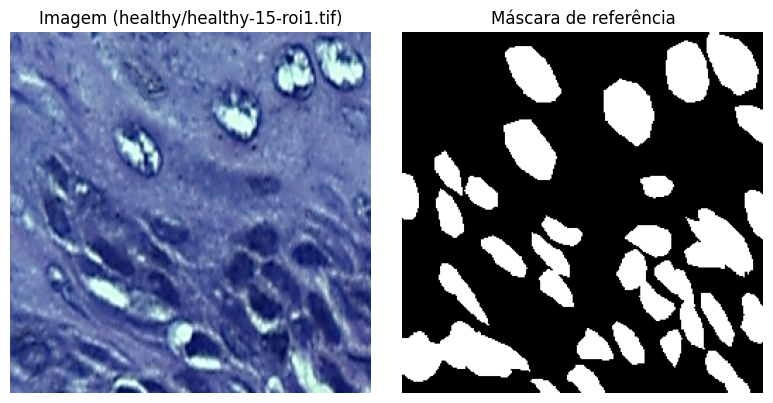

In [15]:
if len(file_list) > 0:
    sample_ds = NucleiSegmentationDataset(file_list, augment=False)
    img, mask, name, group = sample_ds[0]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img.permute(1, 2, 0).numpy())
    axes[0].set_title(f"Imagem ({group}/{name})")
    axes[0].axis("off")
    axes[1].imshow(mask.numpy(), cmap="gray")
    axes[1].set_title("Máscara de referência")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum arquivo encontrado — verifique os caminhos do dataset.")


## 5. Métricas de avaliação

Implementação de **Dice**, **Acurácia de pixels** e **IoU** para segmentação
binária (classe 1 = núcleo), calculadas por imagem e depois agregadas pela
média.


In [16]:
@torch.no_grad()
def compute_metrics(pred_mask, true_mask, eps=1e-7):
    """pred_mask, true_mask: tensores binários (0/1) de mesma forma (H, W) ou (N, H, W)."""
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum(dim=(-2, -1))
    pred_sum = pred_mask.sum(dim=(-2, -1))
    true_sum = true_mask.sum(dim=(-2, -1))
    union = pred_sum + true_sum - intersection

    dice = (2 * intersection + eps) / (pred_sum + true_sum + eps)
    iou = (intersection + eps) / (union + eps)

    correct = (pred_mask == true_mask).float().sum(dim=(-2, -1))
    total = torch.numel(true_mask[0]) if true_mask.dim() > 1 else torch.numel(true_mask)
    pixel_acc = correct / total

    return dice, iou, pixel_acc


## 6. Loop de treinamento

Função genérica de treinamento/validação, reutilizada pelos dois
experimentos. Registra loss e métricas (Dice/IoU/acurácia) por época.


In [17]:
def train_model(model, train_loader, val_loader, num_epochs, lr, optimizer_name="Adam",
                 weight_decay=0.0, log_prefix=""):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Otimizador não suportado: {optimizer_name}")

    history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": [], "val_acc": []}
    best_val_dice = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        # ---- treino ----
        model.train()
        running_loss = 0.0
        for images, masks, _, _ in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- validação ----
        model.eval()
        val_running_loss = 0.0
        dice_scores, iou_scores, acc_scores = [], [], []
        with torch.no_grad():
            for images, masks, _, _ in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_running_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                dice, iou, acc = compute_metrics(preds, masks)
                dice_scores.append(dice)
                iou_scores.append(iou)
                acc_scores.append(acc)

        val_loss = val_running_loss / len(val_loader.dataset)
        val_dice = torch.cat(dice_scores).mean().item()
        val_iou = torch.cat(iou_scores).mean().item()
        val_acc = torch.cat(acc_scores).mean().item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        history["val_acc"].append(val_acc)

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_state = copy.deepcopy(model.state_dict())

        print(f"{log_prefix}Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_dice={val_dice:.4f} | val_iou={val_iou:.4f} | val_acc={val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


In [18]:
@torch.no_grad()
def evaluate_and_save_masks(model, loader, output_subdir, save_masks=True):
    """Avalia o modelo no loader fornecido, retorna as métricas médias e
    (opcionalmente) salva as máscaras preditas em
    OUTPUT_MASKS_DIR/output_subdir/<grupo>/<nome_arquivo>."""
    model.eval()
    dice_scores, iou_scores, acc_scores = [], [], []

    save_dir = os.path.join(OUTPUT_MASKS_DIR, output_subdir)
    if save_masks:
        for g in GROUPS:
            os.makedirs(os.path.join(save_dir, g), exist_ok=True)

    for images, masks, names, groups in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        dice, iou, acc = compute_metrics(preds, masks)
        dice_scores.append(dice)
        iou_scores.append(iou)
        acc_scores.append(acc)

        if save_masks:
            for i in range(preds.shape[0]):
                pred_np = (preds[i].cpu().numpy() * 255).astype(np.uint8)
                out_path = os.path.join(save_dir, groups[i], names[i])
                cv2.imwrite(out_path, pred_np)

    metrics = {
        "dice": torch.cat(dice_scores).mean().item(),
        "iou": torch.cat(iou_scores).mean().item(),
        "pixel_acc": torch.cat(acc_scores).mean().item(),
    }
    return metrics


## 7. Experimento 1 — U-Net sem aumento de dados

**Configuração registrada:**

| Parâmetro | Valor |
|---|---|
| Épocas | 30 |
| Tamanho do batch | 8 |
| Taxa de aprendizado | 1e-3 |
| Otimizador | Adam |
| Função de perda | CrossEntropyLoss |
| Aumento de dados | Nenhum |

Ajuste `NUM_EPOCHS_EXP1` / `LR_EXP1` conforme o comportamento observado nas
curvas de treino (por exemplo, se houver overfitting, considere reduzir
épocas ou aumentar dropout).


In [19]:
NUM_EPOCHS_EXP1 = 30
LR_EXP1 = 1e-3

train_loader_1, val_loader_1, test_loader_1 = make_loaders(augment_train=False)

model_exp1 = UNet(in_channels=3, num_classes=2, dropout_rate=0.1, batchnorm=True)

model_exp1, history_exp1 = train_model(
    model_exp1, train_loader_1, val_loader_1,
    num_epochs=NUM_EPOCHS_EXP1, lr=LR_EXP1, optimizer_name="Adam",
    log_prefix="[Exp.1] ",
)


[Exp.1] Epoch 01/30 | train_loss=0.4868 | val_loss=0.8033 | val_dice=0.0131 | val_iou=0.0068 | val_acc=0.6958
[Exp.1] Epoch 02/30 | train_loss=0.4048 | val_loss=2.0230 | val_dice=0.4828 | val_iou=0.3224 | val_acc=0.3741
[Exp.1] Epoch 03/30 | train_loss=0.3893 | val_loss=0.5009 | val_dice=0.6480 | val_iou=0.4840 | val_acc=0.7519
[Exp.1] Epoch 04/30 | train_loss=0.3817 | val_loss=0.4285 | val_dice=0.6808 | val_iou=0.5222 | val_acc=0.7964
[Exp.1] Epoch 05/30 | train_loss=0.3689 | val_loss=0.4218 | val_dice=0.7067 | val_iou=0.5542 | val_acc=0.8000
[Exp.1] Epoch 06/30 | train_loss=0.3737 | val_loss=0.5701 | val_dice=0.5858 | val_iou=0.4206 | val_acc=0.7961
[Exp.1] Epoch 07/30 | train_loss=0.3641 | val_loss=0.3927 | val_dice=0.7005 | val_iou=0.5497 | val_acc=0.8213
[Exp.1] Epoch 08/30 | train_loss=0.3606 | val_loss=0.4118 | val_dice=0.7190 | val_iou=0.5676 | val_acc=0.8108
[Exp.1] Epoch 09/30 | train_loss=0.3569 | val_loss=0.3879 | val_dice=0.6967 | val_iou=0.5470 | val_acc=0.8301
[Exp.1] Ep

In [20]:
test_metrics_exp1 = evaluate_and_save_masks(
    model_exp1, test_loader_1, output_subdir="exp1_sem_augmentation", save_masks=True
)
print("Métricas de teste — Experimento 1 (sem aumento de dados):")
print(json.dumps(test_metrics_exp1, indent=2))


Métricas de teste — Experimento 1 (sem aumento de dados):
{
  "dice": 0.7399733066558838,
  "iou": 0.5915411710739136,
  "pixel_acc": 0.8605355620384216
}


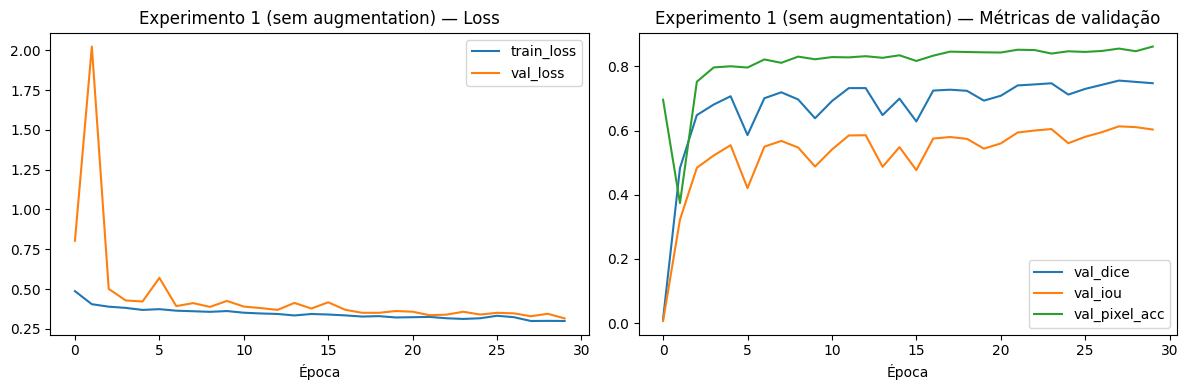

In [21]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history["val_dice"], label="val_dice")
    axes[1].plot(history["val_iou"], label="val_iou")
    axes[1].plot(history["val_acc"], label="val_pixel_acc")
    axes[1].set_title(f"{title} — Métricas de validação")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_exp1, "Experimento 1 (sem augmentation)")


## 8. Experimento 2 — U-Net com aumento de dados geométrico

**Configuração registrada:**

| Parâmetro | Valor |
|---|---|
| Épocas | 30 |
| Tamanho do batch | 8 |
| Taxa de aprendizado | 1e-3 |
| Otimizador | Adam |
| Função de perda | CrossEntropyLoss |
| Aumento de dados | Geométrico (rotação, flips H/V, transposição, recorte leve) |

Somente transformações **geométricas** são aplicadas (nenhuma alteração de
cor, brilho, contraste, saturação ou ruído), conforme a implementação em
`NucleiSegmentationDataset._geometric_augment`.


In [22]:
NUM_EPOCHS_EXP2 = 30
LR_EXP2 = 1e-3

train_loader_2, val_loader_2, test_loader_2 = make_loaders(augment_train=True)

model_exp2 = UNet(in_channels=3, num_classes=2, dropout_rate=0.1, batchnorm=True)

model_exp2, history_exp2 = train_model(
    model_exp2, train_loader_2, val_loader_2,
    num_epochs=NUM_EPOCHS_EXP2, lr=LR_EXP2, optimizer_name="Adam",
    log_prefix="[Exp.2] ",
)


[Exp.2] Epoch 01/30 | train_loss=0.5643 | val_loss=0.7164 | val_dice=0.4224 | val_iou=0.2698 | val_acc=0.5501
[Exp.2] Epoch 02/30 | train_loss=0.4363 | val_loss=0.4747 | val_dice=0.5478 | val_iou=0.3931 | val_acc=0.7850
[Exp.2] Epoch 03/30 | train_loss=0.4191 | val_loss=1.2016 | val_dice=0.5565 | val_iou=0.3973 | val_acc=0.5407
[Exp.2] Epoch 04/30 | train_loss=0.4098 | val_loss=0.7889 | val_dice=0.4607 | val_iou=0.3118 | val_acc=0.7509
[Exp.2] Epoch 05/30 | train_loss=0.3949 | val_loss=0.4400 | val_dice=0.6620 | val_iou=0.5028 | val_acc=0.7962
[Exp.2] Epoch 06/30 | train_loss=0.3926 | val_loss=0.4961 | val_dice=0.5802 | val_iou=0.4215 | val_acc=0.7836
[Exp.2] Epoch 07/30 | train_loss=0.3900 | val_loss=0.4172 | val_dice=0.6732 | val_iou=0.5139 | val_acc=0.8108
[Exp.2] Epoch 08/30 | train_loss=0.3838 | val_loss=0.4155 | val_dice=0.6340 | val_iou=0.4804 | val_acc=0.8131
[Exp.2] Epoch 09/30 | train_loss=0.3866 | val_loss=0.6300 | val_dice=0.3597 | val_iou=0.2329 | val_acc=0.7440
[Exp.2] Ep

In [23]:
test_metrics_exp2 = evaluate_and_save_masks(
    model_exp2, test_loader_2, output_subdir="exp2_com_augmentation_geometrica", save_masks=True
)
print("Métricas de teste — Experimento 2 (com aumento de dados geométrico):")
print(json.dumps(test_metrics_exp2, indent=2))


Métricas de teste — Experimento 2 (com aumento de dados geométrico):
{
  "dice": 0.6888957619667053,
  "iou": 0.5301658511161804,
  "pixel_acc": 0.8258161544799805
}


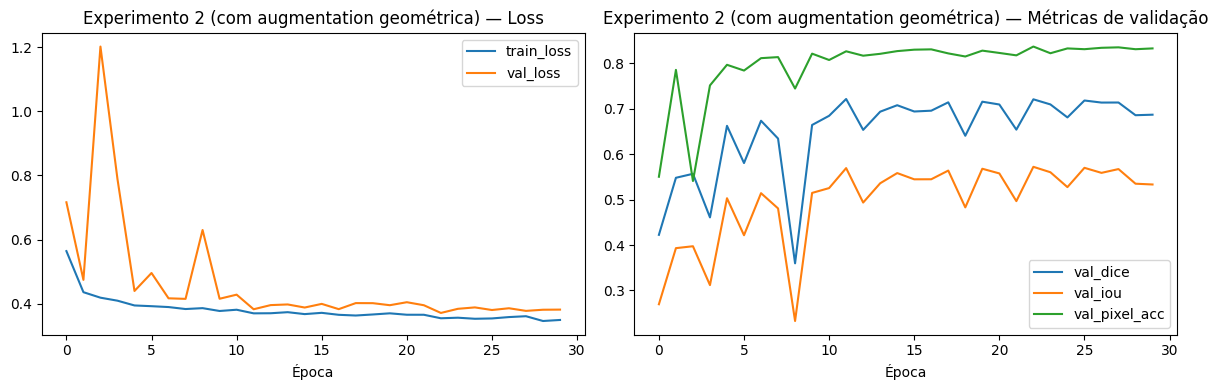

In [24]:
plot_history(history_exp2, "Experimento 2 (com augmentation geométrica)")


## 9. Comparação dos experimentos

Consolida as métricas de teste (Dice, IoU, Acurácia de pixels) dos dois
experimentos e salva um resumo em CSV no Drive, junto às máscaras preditas em
`unet_masks/`.


In [25]:
import pandas as pd

results_df = pd.DataFrame([
    {"experimento": "Exp.1 - sem augmentation", **test_metrics_exp1,
     "epochs": NUM_EPOCHS_EXP1, "batch_size": BATCH_SIZE, "lr": LR_EXP1,
     "optimizer": "Adam", "loss": "CrossEntropyLoss"},
    {"experimento": "Exp.2 - com augmentation geometrica", **test_metrics_exp2,
     "epochs": NUM_EPOCHS_EXP2, "batch_size": BATCH_SIZE, "lr": LR_EXP2,
     "optimizer": "Adam", "loss": "CrossEntropyLoss"},
])

display(results_df)

results_csv_path = os.path.join(OUTPUT_MASKS_DIR, "resultados_experimentos.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Resumo dos experimentos salvo em: {results_csv_path}")
print(f"Máscaras preditas salvas em: {OUTPUT_MASKS_DIR}")


,experimento,dice,iou,pixel_acc,epochs,batch_size,lr,optimizer,loss
0,Exp.1 - sem augmentation,0.739973,0.591541,0.860536,30,8,0.001,Adam,CrossEntropyLoss
1,Exp.2 - com augmentation geometrica,0.688896,0.530166,0.825816,30,8,0.001,Adam,CrossEntropyLoss


Resumo dos experimentos salvo em: /content/drive/MyDrive/LIPAI/S19/unet_masks/resultados_experimentos.csv
Máscaras preditas salvas em: /content/drive/MyDrive/LIPAI/S19/unet_masks


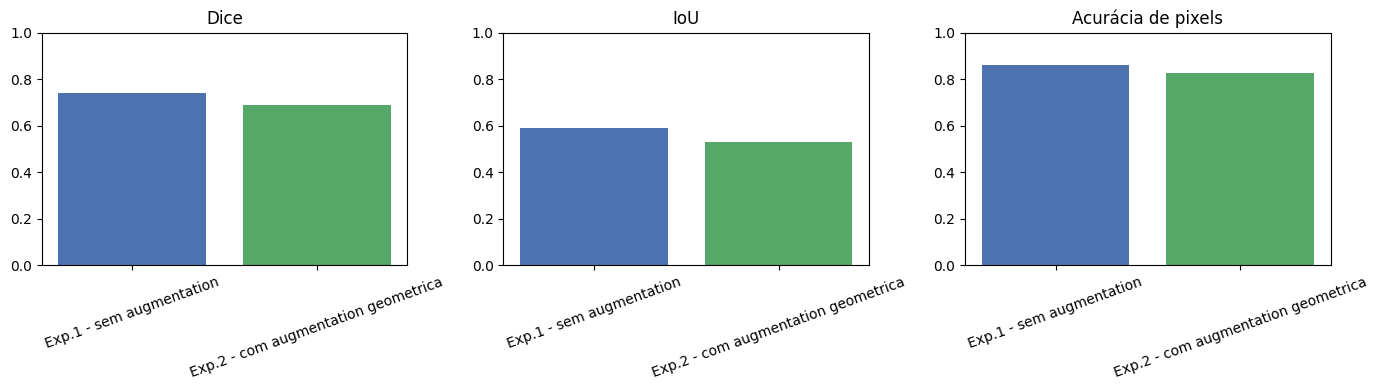

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_names = ["dice", "iou", "pixel_acc"]
titles = ["Dice", "IoU", "Acurácia de pixels"]

for ax, metric, title in zip(axes, metrics_names, titles):
    ax.bar(results_df["experimento"], results_df[metric], color=["#4C72B0", "#55A868"])
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 10. Visualização qualitativa (opcional)

Compara, para algumas amostras do conjunto de teste, a imagem original, a
máscara de referência e as máscaras preditas pelos dois modelos.


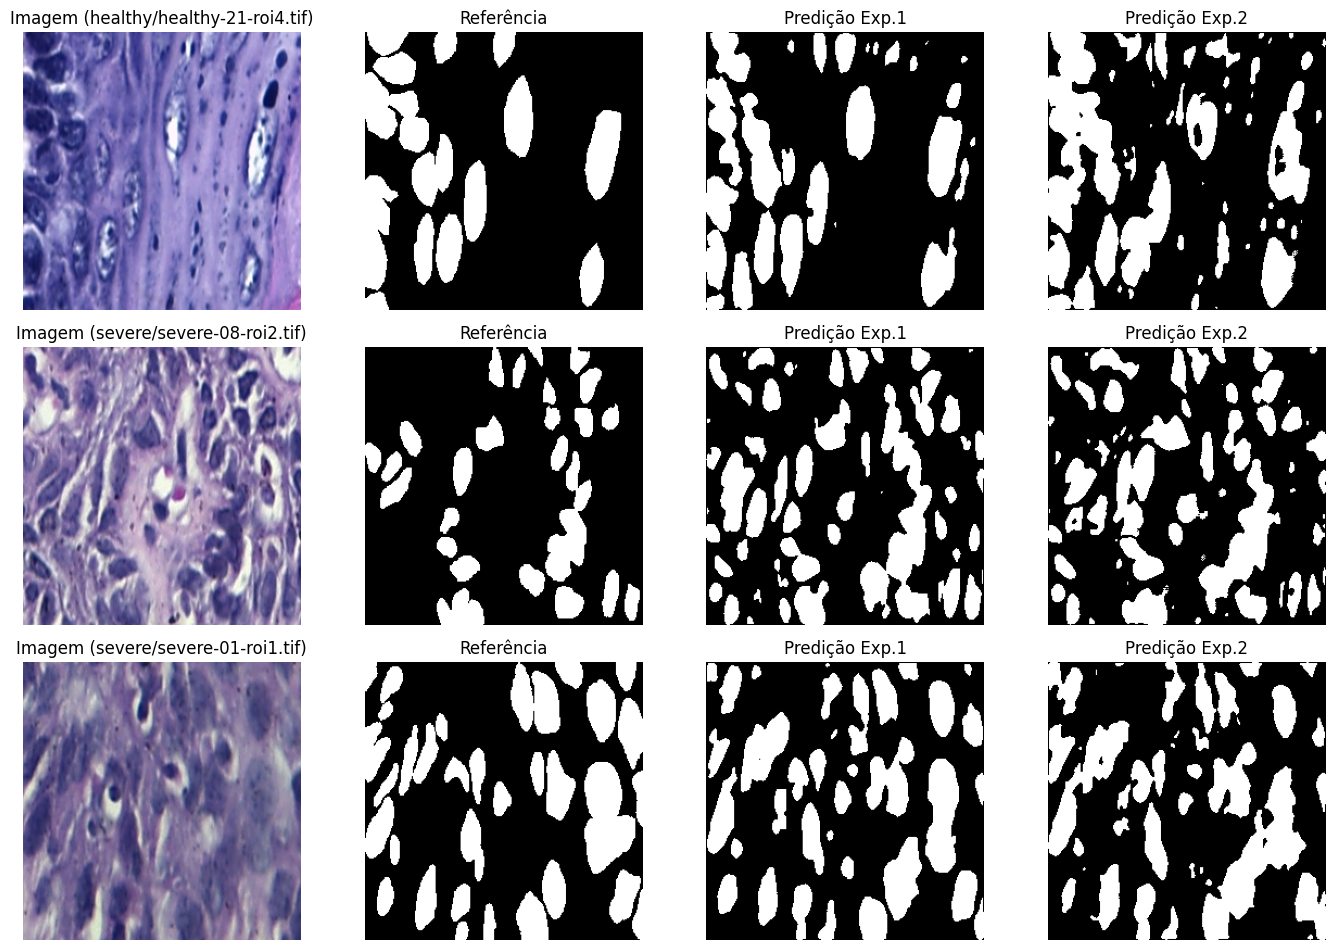

In [27]:
@torch.no_grad()
def show_qualitative_comparison(model_a, model_b, loader, n_samples=3,
                                 label_a="Exp.1", label_b="Exp.2"):
    model_a.eval()
    model_b.eval()
    shown = 0
    fig, axes = plt.subplots(n_samples, 4, figsize=(14, 3.2 * n_samples))
    if n_samples == 1:
        axes = axes[None, :]

    for images, masks, names, groups in loader:
        if shown >= n_samples:
            break
        images_d = images.to(device)
        pred_a = torch.argmax(model_a(images_d), dim=1).cpu()
        pred_b = torch.argmax(model_b(images_d), dim=1).cpu()

        axes[shown, 0].imshow(images[0].permute(1, 2, 0).numpy())
        axes[shown, 0].set_title(f"Imagem ({groups[0]}/{names[0]})")
        axes[shown, 1].imshow(masks[0].numpy(), cmap="gray")
        axes[shown, 1].set_title("Referência")
        axes[shown, 2].imshow(pred_a[0].numpy(), cmap="gray")
        axes[shown, 2].set_title(f"Predição {label_a}")
        axes[shown, 3].imshow(pred_b[0].numpy(), cmap="gray")
        axes[shown, 3].set_title(f"Predição {label_b}")
        for j in range(4):
            axes[shown, j].axis("off")
        shown += 1

    plt.tight_layout()
    plt.show()

show_qualitative_comparison(model_exp1, model_exp2, test_loader_1, n_samples=3)


## Notas finais

- Os pesos dos modelos treinados não são salvos automaticamente neste
  notebook; use `torch.save(model_exp1.state_dict(), <caminho>)` se quiser
  persistir os modelos no Drive.
- Os hiperparâmetros (`NUM_EPOCHS_EXP1/2`, `LR_EXP1/2`, `BATCH_SIZE`,
  `IMG_SIZE`) foram definidos como ponto de partida razoável; ajuste-os
  conforme o tamanho real do dataset e o comportamento das curvas de
  treino/validação.
- Caso a estrutura de diretórios do dataset/máscaras seja diferente da
  assumida, edite apenas a função `build_file_list()` — o restante do
  pipeline (dataset, modelo, treino, métricas) não precisa ser alterado.
